In [1]:
# Loading some required liberaries
from __future__ import division
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
from scipy import interpolate 
#from cmcrameri import cm 

import V2RhoT_gibbs_lib as lib


import matplotlib.pyplot as plt

# Set publication/Nature style parameters
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 7,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 6,
    'legend.frameon': False,
    'lines.linewidth': 1.0,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5
})

In [13]:
table_PUM = np.loadtxt('./../databases/PUM_HP',comments='#') 
table_DMM = np.loadtxt('./../databases/DMM_HP',comments='#') 
table_Arc_1 = np.loadtxt('./../databases/Arc_1_HP',comments='#') 
table_Pr_1 = np.loadtxt('./../databases/Pr_1_DB5',comments='#') 
table_Tc_1 =np.loadtxt('./../databases/Tc_1_db5')
grain_size=10 # in mm
oscillation_period=100 # in seconds
COH=100
TABLE_DMM_corr=lib.mantle_melt_atten_correction_Behn2009(table_DMM,grain_size,oscillation_period,COH)

In [ ]:
# Effect of alpha

In [10]:

# Function mantle_melt_atten_correction implements the corrections.
# Note: I have included a description for most of the functions (if you want to know what are the arguments of these functions, just press shift tab). 
grain_size=10 # in mm
oscillation_period=100 # in seconds
COH=100

TABLE_PUM_corr=lib.mantle_melt_atten_correction_Behn2009(table_PUM,grain_size,oscillation_period,COH)
TABLE_DMM_corr=lib.mantle_melt_atten_correction_Behn2009(table_DMM,grain_size,oscillation_period,COH)
#TABLE_PUM_corr_=lib_new.mantle_melt_atten_correction_Behn2009(table_PUM,grain_size,oscillation_period,COH)

TABLE_Arc_1_corr=lib.mantle_melt_atten_correction_Behn2009(table_Arc_1,grain_size,oscillation_period,COH)
TABLE_Pr_1_corr=lib.mantle_melt_atten_correction_Behn2009(table_Pr_1,grain_size,oscillation_period,COH)
TABLE_Tc_1_corr=lib.mantle_melt_atten_correction_Behn2009(table_Tc_1,grain_size,oscillation_period,COH)


In [11]:
# Please make sure that you are following the ordering of x y z and velocity. For more info see the -h option in parrallel_conversion.py or Guidelines in the Gitlab. 
tomo_in = np.loadtxt('./../data_tomo/ak135f_to_convert.txt',comments='#')
#Output: Output: [depth,P_out,Temperature_out,Density_out,Vp_out,Vs_out,diff_Vp,melt_out)
DMM= lib.vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_PUM_corr);
#PUM_new= lib_new.vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_PUM_corr);
Pr1= lib.vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_Pr_1_corr);
Arc1= lib.vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_Arc_1_corr);
Tc1= lib.vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_Tc_1_corr);


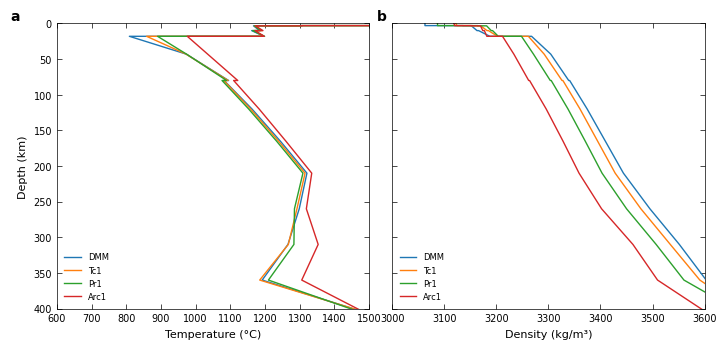

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.5), sharey=True)

ax0 = axes[0]
# Plotting profiles
ax0.plot(DMM[:, 2], DMM[:, 0], label='DMM')
ax0.plot(Tc1[:, 2], Tc1[:, 0], label='Tc1')
ax0.plot(Pr1[:, 2], Pr1[:, 0], label='Pr1')
ax0.plot(Arc1[:, 2], Arc1[:, 0], label='Arc1')
# Formatting panel A
ax0.set_xlim(600, 1500)
ax0.set_xlabel('Temperature (°C)')
ax0.set_ylabel('Depth (km)')
ax0.legend(loc='lower left')
ax0.text(-0.15, 1.05, 'a', transform=ax0.transAxes, fontsize=10, fontweight='bold', va='top') # Nature panel label

ax1 = axes[1]
# Plotting profiles
ax1.plot(DMM[:, 3], DMM[:, 0], label='DMM')
ax1.plot(Tc1[:, 3], Tc1[:, 0], label='Tc1')
ax1.plot(Pr1[:, 3], Pr1[:, 0], label='Pr1')
ax1.plot(Arc1[:, 3], Arc1[:, 0], label='Arc1')
# Formatting panel B
ax1.set_xlim(3000, 3600)
ax1.set_xlabel('Density (kg/m³)')
ax1.text(-0.05, 1.05, 'b', transform=ax1.transAxes, fontsize=10, fontweight='bold', va='top')
# Only one legend is needed since the labels/colors match across panels
ax1.legend(loc='lower left')

for ax in axes:
    ax.set_ylim(400, 0) # Keeps the inverted depth scale
    ax.tick_params(direction='in', top=True, right=True) # Nature-style interior ticks

plt.tight_layout()
plt.show()

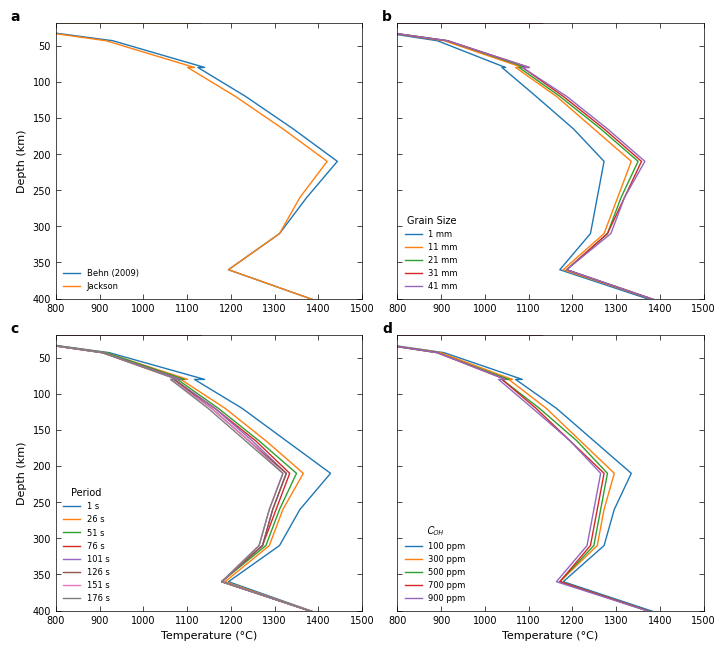

In [37]:
# Create a 2x2 grid sharing the depth (y) axis across columns
fig, axes = plt.subplots(2, 2, figsize=(7.2, 6.5), sharey=True)

# Unpack axes for easier readability
((ax_a, ax_b), (ax_c, ax_d)) = axes

# Global baseline constants
grain_size_base = 10
period_base = 100
coh_base = 100
# ----------------------------------------------------
# Panel A: Model Comparison (Behn vs Jackson)
# ----------------------------------------------------
# Behn 2009 Profile (table, grain_size, period, COH)
TABLE_DMM_corr = lib.mantle_melt_atten_correction_Behn2009(table_DMM, grain_size_base, period_base, 1)
PUM_behn = lib.vel_vs_to_temp_prop_out(tomo_in[:, 0], tomo_in[:, 3], TABLE_DMM_corr)
ax_a.plot(PUM_behn[:, 2], PUM_behn[:, 0], label='Behn (2009)')
# Jackson Profile (table, grain_size, period)
TABLE_PUM_corr = lib.mantle_melt_atten_correction(table_PUM, grain_size_base, period_base)
PUM_jack = lib.vel_vs_to_temp_prop_out(tomo_in[:, 0], tomo_in[:, 3], TABLE_PUM_corr)
ax_a.plot(PUM_jack[:, 2], PUM_jack[:, 0], label='Jackson')

ax_a.legend(loc='lower left')
ax_a.set_ylabel('Depth (km)')
ax_a.text(-0.15, 1.05, 'a', transform=ax_a.transAxes, fontsize=10, fontweight='bold', va='top')

# ----------------------------------------------------
# Panel B: Sensitivity to Grain Size
# ----------------------------------------------------
for grain_size in range(1, 50, 10):
    # Fixed period=100, COH=100 passed positionally
    TABLE_PUM_corr = lib.mantle_melt_atten_correction_Behn2009(table_PUM, grain_size, 100, 100)
    DMM = lib.vel_vs_to_temp_prop_out(tomo_in[:, 0], tomo_in[:, 3], TABLE_PUM_corr)
    ax_b.plot(DMM[:, 2], DMM[:, 0], label=f'{grain_size} mm')
ax_b.legend(title='Grain Size', loc='lower left')
ax_b.text(-0.05, 1.05, 'b', transform=ax_b.transAxes, fontsize=10, fontweight='bold', va='top')
# ----------------------------------------------------
# Panel C: Sensitivity to Oscillation Period
# ----------------------------------------------------
for oscillation_period in range(1, 200, 25):
    # Fixed grain_size=grain_size_base, COH=100 passed positionally
    TABLE_PUM_corr = lib.mantle_melt_atten_correction_Behn2009(table_PUM, grain_size_base, oscillation_period, 100)
    DMM = lib.vel_vs_to_temp_prop_out(tomo_in[:, 0], tomo_in[:, 3], TABLE_PUM_corr)
    ax_c.plot(DMM[:, 2], DMM[:, 0], label=f'{oscillation_period} s')

ax_c.legend(title='Period', loc='lower left')
ax_c.set_xlabel('Temperature (°C)')
ax_c.set_ylabel('Depth (km)')
ax_c.text(-0.15, 1.05, 'c', transform=ax_c.transAxes, fontsize=10, fontweight='bold', va='top')


# ----------------------------------------------------
# Panel D: Sensitivity to Water Content (C_OH)
# ----------------------------------------------------
for COH in range(100, 1000, 200):
    # Fixed grain_size=grain_size_base, period=100 passed positionally
    TABLE_PUM_corr = lib.mantle_melt_atten_correction_Behn2009(table_PUM, grain_size_base, 100, COH)
    DMM = lib.vel_vs_to_temp_prop_out(tomo_in[:, 0], tomo_in[:, 3], TABLE_PUM_corr)
    ax_d.plot(DMM[:, 2], DMM[:, 0], label=f'{COH} ppm')

ax_d.legend(title=r'$C_{OH}$', loc='lower left')
ax_d.set_xlabel('Temperature (°C)')
ax_d.text(-0.05, 1.05, 'd', transform=ax_d.transAxes, fontsize=10, fontweight='bold', va='top')

# ----------------------------------------------------
# Global Layout Cleanups
# ----------------------------------------------------
for ax in axes.flat:
    ax.set_xlim(800, 1500)
    ax.set_ylim(400, 19)   # Inverted depth scale
    ax.tick_params(direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Effect of atten model

Text(0, 0.5, 'Depth (km)')

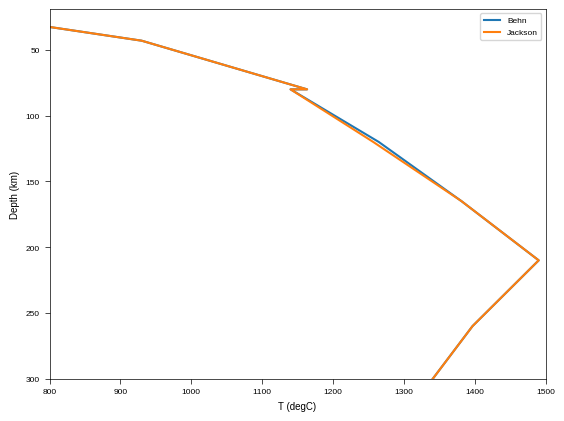

In [13]:
fig, axes = plt.subplots(1, 1, sharex=False, sharey=False)#, figsize=(20,15)) 
#
ax=axes

grain_size=10
oscillation_period=1
COH=1
TABLE_PUM_corr=lib.mantle_melt_atten_correction_Behn2009(table_PUM,grain_size,oscillation_period,COH)
PUM= lib.vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_PUM_corr);
use=PUM.copy()
xplot=2 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='Behn')

TABLE_PUM_corr=lib.mantle_melt_atten_correction(table_PUM,grain_size,oscillation_period)
PUM= lib.vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_PUM_corr);
use=PUM.copy()
xplot=2 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='Jackson')

ax.set_ylim(300,19)
ax.legend()
ax.set_xlim(800,1500)
ax.set_xlabel('T (degC)');ax.set_ylabel('Depth (km)')

# Effect of grain size


Text(0, 0.5, 'Depth (km)')

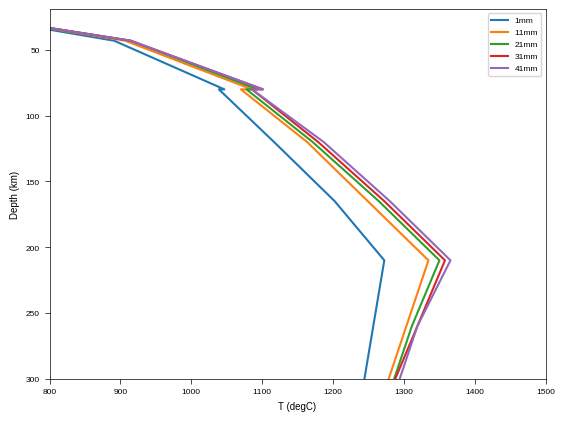

In [14]:
fig, axes = plt.subplots(1, 1, sharex=False, sharey=False)#, figsize=(20,15)) 
#
ax=axes
COH=100
oscillation_period=100
for grain_size in range(1,50,10):
    #PUM
    TABLE_PUM_corr=lib.mantle_melt_atten_correction_Behn2009(table_PUM,grain_size,oscillation_period,COH)
    PUM= lib.vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_PUM_corr);
    use=PUM.copy()
    xplot=2 #T
    yplot=0 #d
    ax.plot(use[:,xplot],use[:,yplot],label=str(grain_size)+'mm')

ax.set_ylim(300,19)
ax.legend()
ax.set_xlim(800,1500)
ax.set_xlabel('T (degC)');ax.set_ylabel('Depth (km)')


# Effect of Oscillation period

Text(0, 0.5, 'Depth (km)')

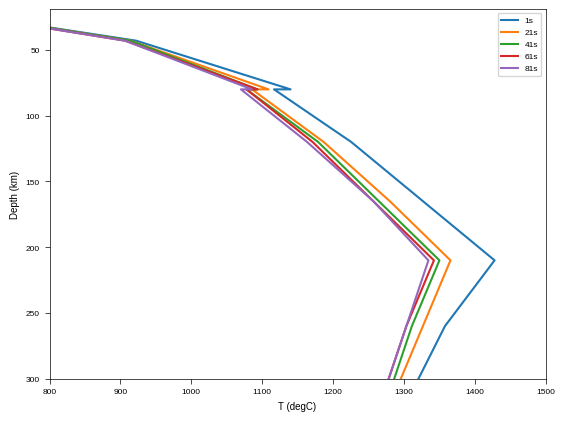

In [15]:
fig, axes = plt.subplots(1, 1, sharex=False, sharey=False)#, figsize=(20,15)) 
#
ax=axes
grain_size=10
COH=100
#oscillation_period=100
for oscillation_period in range(1,100,20):
    #PUM
    TABLE_PUM_corr=lib.mantle_melt_atten_correction_Behn2009(table_PUM,grain_size,oscillation_period,COH)
    PUM= lib.vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_PUM_corr);
    use=PUM.copy()
    xplot=2 #T
    yplot=0 #d
    ax.plot(use[:,xplot],use[:,yplot],label=str(oscillation_period)+'s')

ax.set_ylim(300,19)
ax.legend()
ax.set_xlim(800,1500)
ax.set_xlabel('T (degC)');ax.set_ylabel('Depth (km)')


# Effect of water COH

Text(0, 0.5, 'Depth (km)')

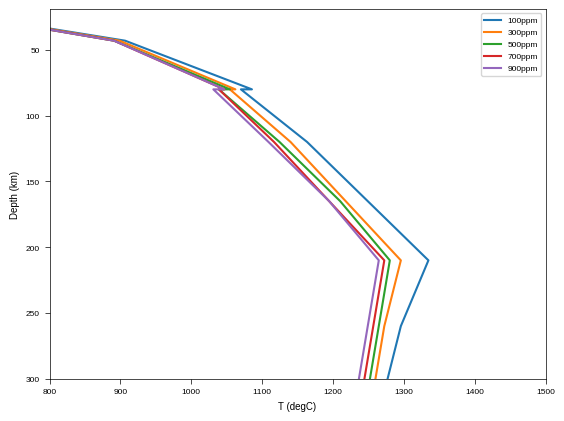

In [16]:
fig, axes = plt.subplots(1, 1, sharex=False, sharey=False)#, figsize=(20,15)) 
#
ax=axes
grain_size=10
oscillation_period=100
for COH in range(100,1000,200):
    #PUM
    TABLE_PUM_corr=lib.mantle_melt_atten_correction_Behn2009(table_PUM,grain_size,oscillation_period,COH)
    PUM= lib.vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_PUM_corr);
    use=PUM.copy()
    xplot=2 #T
    yplot=0 #d
    ax.plot(use[:,xplot],use[:,yplot],label=str(COH)+'ppm')

ax.set_ylim(300,19)
ax.legend()
ax.set_xlim(800,1500)
ax.set_xlabel('T (degC)');ax.set_ylabel('Depth (km)')


In [17]:
#Output: Output: [depth,P_out,Temperature_out,Density_out,Vp_out,Vs_out,diff_Vp,melt_out)
PUM= lib.vel_vp_to_temp_prop_out(tomo_in[:,0],tomo_in[:,2],TABLE_PUM_corr);
Pr1= lib.vel_vp_to_temp_prop_out(tomo_in[:,0],tomo_in[:,2],TABLE_Pr_1_corr);
Arc1= lib.vel_vp_to_temp_prop_out(tomo_in[:,0],tomo_in[:,2],TABLE_Arc_1_corr);


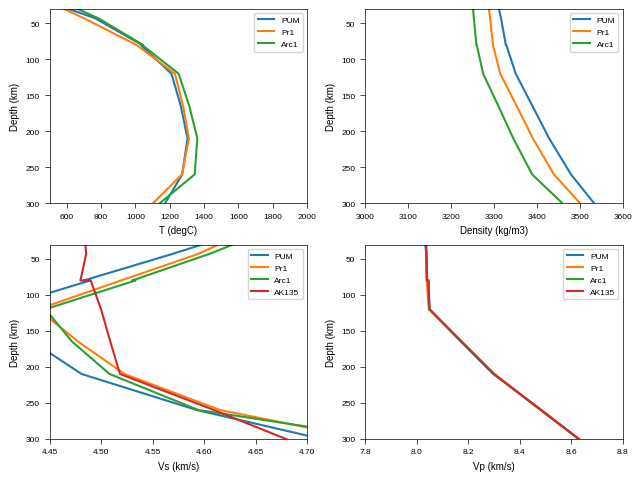

In [18]:
fig, axes = plt.subplots(2, 2, sharex=False, sharey=False)#, figsize=(20,15)) 
#
ax=axes[0,0]
#PUM
use=PUM.copy()
xplot=2 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='PUM')
#Pr1
use=Pr1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Pr1')
#Arc
use=Arc1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Arc1')
ax.legend()
ax.set_xlim(500,2000)
ax.set_xlabel('T (degC)');ax.set_ylabel('Depth (km)')


#density
ax=axes[0,1]
#PUM
use=PUM.copy()
xplot=3 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='PUM')
#Pr1
use=Pr1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Pr1')
#Arc
use=Arc1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Arc1')
ax.legend()
ax.set_xlim(3000,3600)
ax.set_xlabel('Density (kg/m3)');ax.set_ylabel('Depth (km)')


#Vs
ax=axes[1,0]
#PUM
use=PUM.copy()
xplot=5 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='PUM')
#Pr1
use=Pr1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Pr1')
#Arc
use=Arc1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Arc1')
ax.plot(tomo_in[:,3],tomo_in[:,0],label='AK135')
ax.legend()
ax.set_xlim(4.45,4.7)#ax.set_xlim(7.5,9)
ax.set_xlabel('Vs (km/s)');ax.set_ylabel('Depth (km)')



#Vp
ax=axes[1,1]
#PUM
use=PUM.copy()
xplot=4 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='PUM')
#Pr1
use=Pr1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Pr1')
#Arc
use=Arc1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Arc1')
ax.plot(tomo_in[:,2],tomo_in[:,0],label='AK135')
ax.legend()
ax.set_xlim(7.8,8.8)
ax.set_xlabel('Vp (km/s)');ax.set_ylabel('Depth (km)')

for i, ax in enumerate(axes.flat):
   ax.set_ylim(300,30)
    

plt.tight_layout()

In [22]:
#Output: Output: [depth,P_out,Temperature_out,Density_out,Vp_out,Vs_out,diff_Vp,melt_out)
PUM= lib.vel_vpvs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,2]/tomo_in[:,3],TABLE_PUM_corr);
Pr1= lib.vel_vp_to_temp_prop_out(tomo_in[:,0],tomo_in[:,2]/tomo_in[:,3],TABLE_Pr_1_corr);
Arc1= lib.vel_vp_to_temp_prop_out(tomo_in[:,0],tomo_in[:,2]/tomo_in[:,3],TABLE_Arc_1_corr);


/tmp/ipykernel_1505259/37867462.py:2: RuntimeWarning: divide by zero encountered in divide
  PUM= lib.vel_vpvs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,2]/tomo_in[:,3],TABLE_PUM_corr);
/home/ajay/projects/V2RhoT_gibbs/V2RhoT_gibbs_lib.py:1156: RuntimeWarning: invalid value encountered in scalar divide
  diff_VpVs.append(((VpVs_in-vp/vs)/VpVs_in)*100)
/tmp/ipykernel_1505259/37867462.py:3: RuntimeWarning: divide by zero encountered in divide
  Pr1= lib.vel_vp_to_temp_prop_out(tomo_in[:,0],tomo_in[:,2]/tomo_in[:,3],TABLE_Pr_1_corr);
/home/ajay/projects/V2RhoT_gibbs/V2RhoT_gibbs_lib.py:1112: RuntimeWarning: invalid value encountered in scalar divide
  diff_Vp.append(((Vp_in-vp)/Vp_in)*100)
/tmp/ipykernel_1505259/37867462.py:4: RuntimeWarning: divide by zero encountered in divide
  Arc1= lib.vel_vp_to_temp_prop_out(tomo_in[:,0],tomo_in[:,2]/tomo_in[:,3],TABLE_Arc_1_corr);


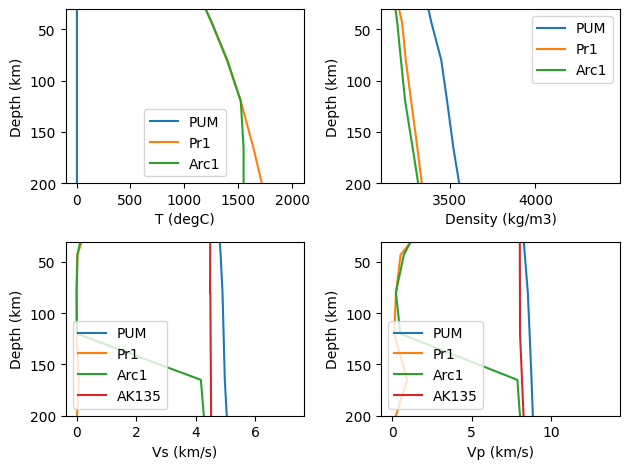

In [23]:
fig, axes = plt.subplots(2, 2, sharex=False, sharey=False)#, figsize=(20,15)) 
#
ax=axes[0,0]
#PUM
use=PUM.copy()
xplot=2 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='PUM')
#Pr1
use=Pr1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Pr1')
#Arc
use=Arc1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Arc1')
ax.legend()
#ax.set_xlim(500,2000)
ax.set_xlabel('T (degC)');ax.set_ylabel('Depth (km)')


#density
ax=axes[0,1]
#PUM
use=PUM.copy()
xplot=3 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='PUM')
#Pr1
use=Pr1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Pr1')
#Arc
use=Arc1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Arc1')
ax.legend()
#ax.set_xlim(3000,3600)
ax.set_xlabel('Density (kg/m3)');ax.set_ylabel('Depth (km)')


#Vs
ax=axes[1,0]
#PUM
use=PUM.copy()
xplot=5 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='PUM')
#Pr1
use=Pr1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Pr1')
#Arc
use=Arc1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Arc1')
ax.plot(tomo_in[:,3],tomo_in[:,0],label='AK135')
ax.legend()
#ax.set_xlim(4.45,4.7)#ax.set_xlim(7.5,9)
ax.set_xlabel('Vs (km/s)');ax.set_ylabel('Depth (km)')



#Vp
ax=axes[1,1]
#PUM
use=PUM.copy()
xplot=4 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='PUM')
#Pr1
use=Pr1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Pr1')
#Arc
use=Arc1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Arc1')
ax.plot(tomo_in[:,2],tomo_in[:,0],label='AK135')
ax.legend()
#ax.set_xlim(7.8,8.8)
ax.set_xlabel('Vp (km/s)');ax.set_ylabel('Depth (km)')

for i, ax in enumerate(axes.flat):
   ax.set_ylim(200,30)
    

plt.tight_layout()